In [1]:
class Value:
    def __init__(self,data,_childeren = (),_op='', label =""):
        self.data = data
        self._prev = set(_childeren)
        self._op = _op 
        self.label = label 
        self.grad = 0 
    
    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        out = Value(self.data + other.data,(self,other), '+')
        return out 
    
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')

        return out 

a = Value(2.0,label='a')
b = Value(3.0, label='c')
c = Value(4.0, label='d')
e = a * b ; e.label = 'e'


d = a * b + c


In [2]:
from graphviz import Digraph

def trace(root):
    """Builds a set of nodes and edges for graphviz"""
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    """Draw the computational graph"""
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left-to-right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Node: value and gradient
        dot.node(name=uid, label= "{%s | data %.4f | grad %.4f}" %(n.label, n.data, n.grad), shape='record')
        if n._op:
            # Operation node
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


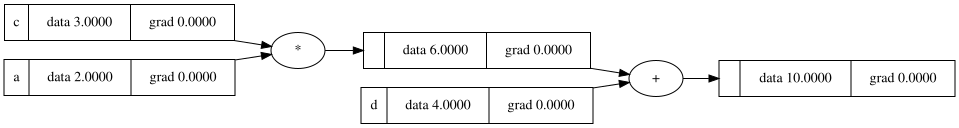

In [3]:
draw_dot(d)